# Notebook 09 — Walk-Forward Out-of-Sample Validation

**Adaptive Pair Trading | Ayush Arora (MQMS2404)**

---

## Why Walk-Forward Validation?

A single train/test split is a weak test — the result could be an artefact of the
split point. Walk-forward validation rolls a 2-year training / 6-month test window
through the history, re-estimating the hedge ratio and spread on each training
window and measuring performance **only on the held-out test period**.

This notebook validates **every pair in `data/top_pairs.csv`** (NB08's ranked
output) — no hardcoded pair — and reports **per pair** (the primary finding) and
**pooled** (secondary, with a dependence caveat).

### What this pass fixed

| Was | Now |
|-----|-----|
| P&L = spread change ÷ mean spread level — no capital base, unbounded, `(1+pnl).cumprod()` crossed zero | Return on **deployed capital** (`config.pair_backtest`): P&L ÷ gross exposure `price_A+\|β\|·price_B`; asserts `min(ret) > -1` |
| Sharpe annualised over active days only (overstated by 1/√time-in-market) | `config.sharpe_ratio` over the **full** daily series, flat days included; time-in-market reported |
| `max_dd` returned garbage if equity ≤ 0 | `config.max_drawdown` raises if equity ≤ 0 |
| One-way TC on one leg (~4× understated) | `COST_BPS_ROUND_TRIP` per two-leg round trip, swept at **10 / 30 / 60 bps**, all reported |
| 18 of 48 pair-windows silently dropped (Sharpe NaN → `.dropna()`) | **Every window kept**; zero-trade windows = defined zero return; trade count & time-in-market shown |
| Pooled t-test on non-independent pair-windows; separate n=3 t-test | n=3 t-test deleted; pooled significance via **stationary block bootstrap** (mean block 20d) on the pooled daily series; cross-pair correlation shown |

The Z-score is unchanged: `config.rolling_zscore` (252/60), OOS path warm-started
with the training-spread tail.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta
import warnings
from config import (
    PRICES_FILE, TOP_PAIRS_FILE,
    ROLL_WINDOW, ROLL_MIN_PERIODS, rolling_zscore,
    ENTRY_Z, EXIT_Z,
    COST_BPS_ROUND_TRIP, COST_BPS_ROUND_TRIP_LEVELS,
    pair_backtest, sharpe_ratio, max_drawdown, stationary_bootstrap,
    WF_TRAIN_MONTHS, WF_TEST_MONTHS,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
COST_LEVELS = list(COST_BPS_ROUND_TRIP_LEVELS)   # (10, 30, 60) bps round trip
print('Libraries loaded. Cost levels (bps round trip):', COST_LEVELS)

Libraries loaded. Cost levels (bps round trip): [10, 30, 60]


In [2]:
prices = pd.read_csv(PRICES_FILE, index_col=0, parse_dates=True)

# ── Pairs to validate: whatever NB08 ranked, no hardcoding ────────────────
if not os.path.exists(TOP_PAIRS_FILE):
    raise FileNotFoundError(
        f'{TOP_PAIRS_FILE} not found. Run _08_Universe_Pair_Scan.ipynb first — '
        'it writes the ranked pair list that this notebook validates out-of-sample.'
    )

top_pairs_df = pd.read_csv(TOP_PAIRS_FILE, index_col=0)
PAIRS = [
    (a, b) for a, b in zip(top_pairs_df['Stock A'], top_pairs_df['Stock B'])
    if a in prices.columns and b in prices.columns
]
if not PAIRS:
    raise ValueError(f'No usable pairs in {TOP_PAIRS_FILE}.')

print(f'Price data: {prices.shape}')
print(f'Walk-forward params: {WF_TRAIN_MONTHS}m train / {WF_TEST_MONTHS}m test')
print(f'Strategy: entry ±{ENTRY_Z}σ, exit ±{EXIT_Z}σ')
print(f'Z-score: config.rolling_zscore (window={ROLL_WINDOW}, min_periods={ROLL_MIN_PERIODS})')
print(f'Transaction cost swept at {COST_LEVELS} bps round trip '
      f'(base case {COST_BPS_ROUND_TRIP} bps)')
print(f'\nValidating {len(PAIRS)} pair(s) from {TOP_PAIRS_FILE}:')
for i, (a, b) in enumerate(PAIRS, 1):
    print(f'  {i}. {a} / {b}')

Price data: (2467, 79)
Walk-forward params: 24m train / 6m test
Strategy: entry ±2.0σ, exit ±0.5σ
Z-score: config.rolling_zscore (window=252, min_periods=60)
Transaction cost swept at [10, 30, 60] bps round trip (base case 30 bps)

Validating 3 pair(s) from data/top_pairs.csv:
  1. DABUR.NS / HINDUNILVR.NS
  2. GRASIM.NS / HINDALCO.NS
  3. HINDALCO.NS / TATASTEEL.NS


## Walk-Forward Engine

The engine runs **every pair from `data/top_pairs.csv`** through the same rolling
windows. For each pair and each window it:

1. **Fits OLS** on the training data → β and α
2. **Builds the spread** on the test data with those fitted parameters
3. **Computes the rolling Z-score** with `config.rolling_zscore` (252/60), warm-started
   with the tail of the training spread — no static train-μ/σ Z-score anywhere
4. **Backtests** with `config.pair_backtest`: P&L is a **return on deployed capital**
   (gross exposure = `price_A + |β|·price_B`), so daily returns are bounded and
   `(1+ret).cumprod()` can never cross zero
5. **Records** Sharpe (over the *full* daily series, flat days included),
   annualised return, max drawdown, time in market, trade count, hit rate —
   **for every window**, including windows the Z-score never triggered (those are
   a real zero-return outcome, not missing data, and are kept)

Everything is repeated at **three transaction-cost levels — 10, 30 and 60 bps
round trip** — and all three are reported. Strategy parameters (`ENTRY_Z`,
`EXIT_Z`) are fixed constants from `config.py`; nothing is optimised per window.

Reporting: **per-pair full-period OOS Sharpe is the primary finding**; the pooled
result is secondary and carries a dependence caveat (shared HINDALCO leg, common
calendar windows), so its significance is assessed with a stationary block
bootstrap rather than a t-test that assumes independent observations.

In [3]:
def ols_spread(a, b):
    model = sm.OLS(a, sm.add_constant(b)).fit()
    beta  = model.params.iloc[1]
    alpha = model.params.iloc[0]
    return a - beta * b - alpha, beta, alpha

def zscore_oos(spread_train, spread_test):
    """Out-of-sample Z-score = the SAME rolling_zscore as everywhere else
    (config / NB03 / NB10), warm-started with the tail of the training spread so
    the first test day already sees a full window. No static train-mean/std
    fallback — that would make the IS/OOS comparison compare two strategies."""
    seed     = spread_train.tail(ROLL_WINDOW)
    combined = pd.concat([seed, spread_test])
    return rolling_zscore(combined).loc[spread_test.index]

def n_trades(pos):
    """Number of round-trip positions opened (0->±1 transitions)."""
    pos = pd.Series(pos)
    return int(((pos != 0) & (pos.shift(1).fillna(0) == 0)).sum())

def hit_rate(ret):
    """% of winning days among days with non-zero P&L."""
    r = pd.Series(ret)
    active = r[r != 0]
    return (active > 0).mean() * 100 if len(active) else np.nan

# P&L, Sharpe and drawdown come from config: pair_backtest / sharpe_ratio /
# max_drawdown. sharpe_ratio uses the full daily series (flat days included);
# max_drawdown raises if the equity curve ever touches zero.
print('Walk-forward engine defined (P&L / Sharpe / drawdown from config).')

Walk-forward engine defined (P&L / Sharpe / drawdown from config).


In [4]:
def build_windows(index, train_months, test_months):
    """Generate (train_start, train_end, test_start, test_end) tuples."""
    windows = []
    start   = index[0]
    end     = index[-1]
    while True:
        train_end  = start + relativedelta(months=train_months) - relativedelta(days=1)
        test_start = train_end + relativedelta(days=1)
        test_end   = test_start + relativedelta(months=test_months) - relativedelta(days=1)
        if test_end > end:
            break
        windows.append((start, train_end, test_start, test_end))
        start = start + relativedelta(months=test_months)   # roll by test window
    return windows

windows = build_windows(prices.index, WF_TRAIN_MONTHS, WF_TEST_MONTHS)
print(f'Walk-forward windows: {len(windows)}')
for i, (ts, te, ss, se) in enumerate(windows, 1):
    print(f'  Window {i:2d}: Train {ts.date()} → {te.date()} | Test {ss.date()} → {se.date()}')

Walk-forward windows: 16
  Window  1: Train 2015-01-01 → 2016-12-31 | Test 2017-01-01 → 2017-06-30
  Window  2: Train 2015-07-01 → 2017-06-30 | Test 2017-07-01 → 2017-12-31
  Window  3: Train 2016-01-01 → 2017-12-31 | Test 2018-01-01 → 2018-06-30
  Window  4: Train 2016-07-01 → 2018-06-30 | Test 2018-07-01 → 2018-12-31
  Window  5: Train 2017-01-01 → 2018-12-31 | Test 2019-01-01 → 2019-06-30
  Window  6: Train 2017-07-01 → 2019-06-30 | Test 2019-07-01 → 2019-12-31
  Window  7: Train 2018-01-01 → 2019-12-31 | Test 2020-01-01 → 2020-06-30
  Window  8: Train 2018-07-01 → 2020-06-30 | Test 2020-07-01 → 2020-12-31
  Window  9: Train 2019-01-01 → 2020-12-31 | Test 2021-01-01 → 2021-06-30
  Window 10: Train 2019-07-01 → 2021-06-30 | Test 2021-07-01 → 2021-12-31
  Window 11: Train 2020-01-01 → 2021-12-31 | Test 2022-01-01 → 2022-06-30
  Window 12: Train 2020-07-01 → 2022-06-30 | Test 2022-07-01 → 2022-12-31
  Window 13: Train 2021-01-01 → 2022-12-31 | Test 2023-01-01 → 2023-06-30
  Window 14: 

In [5]:
def walk_forward_pair(a_col, b_col, cost_bps):
    """Walk-forward backtest for one pair at one cost level.
    Returns (results_df with one row per window, list of per-window daily-return Series)."""
    A, B = prices[a_col], prices[b_col]
    rows, ret_windows = [], []
    for i, (train_s, train_e, test_s, test_e) in enumerate(windows, 1):
        a_train = A.loc[train_s:train_e].dropna()
        b_train = B.loc[train_s:train_e].dropna()
        a_test  = A.loc[test_s:test_e].dropna()
        b_test  = B.loc[test_s:test_e].dropna()
        if len(a_train) < 60 or len(a_test) < 20:
            continue                      # data-sufficiency guard only, not an outcome filter

        spread_train, beta, alpha = ols_spread(a_train, b_train)
        spread_test = a_test - beta * b_test - alpha
        z_test = zscore_oos(spread_train, spread_test)

        bt = pair_backtest(a_test, b_test, beta, z_test, cost_bps_round_trip=cost_bps)
        r = bt['ret'].copy()
        r.name = f'{a_col}/{b_col}'

        rows.append({
            'Pair':               f'{a_col}/{b_col}',
            'Window':             i,
            'Test Start':         test_s.date(),
            'Test End':           test_e.date(),
            'Beta (OLS)':         round(beta, 4),
            'Trades':             n_trades(bt['pos']),
            'Time in Mkt %':      round(bt['in_market'].mean() * 100, 1),
            'OOS Return % (ann)': round(r.mean() * 252 * 100, 2),
            'OOS Sharpe':         round(sharpe_ratio(r), 3),
            'OOS Max DD %':       round(max_drawdown(r), 2),
            'Hit Rate %':         round(hit_rate(r), 1),
        })
        ret_windows.append(r)
    return pd.DataFrame(rows), ret_windows


print(f'Running walk-forward over {len(PAIRS)} pair(s) x {len(windows)} windows '
      f'x {len(COST_LEVELS)} cost levels...\n')

# wf[cost][(a,b)] -> results_df ;  oos_ret[cost][(a,b)] -> [per-window daily-return Series]
wf, oos_ret = {}, {}
for cost in COST_LEVELS:
    wf[cost], oos_ret[cost] = {}, {}
    for a_col, b_col in PAIRS:
        wdf, rw = walk_forward_pair(a_col, b_col, cost)
        wf[cost][(a_col, b_col)] = wdf
        oos_ret[cost][(a_col, b_col)] = rw

# One flat table across all cost levels
frames = []
for cost in COST_LEVELS:
    for (a_col, b_col), wdf in wf[cost].items():
        w = wdf.copy()
        w.insert(0, 'Cost bps', cost)
        frames.append(w)
wf_df_all = pd.concat(frames, ignore_index=True)

n_pair_windows = len(wf[COST_LEVELS[0]][PAIRS[0]]) * len(PAIRS)
n_zero_trade   = int((wf_df_all[wf_df_all['Cost bps'] == COST_BPS_ROUND_TRIP]['Trades'] == 0).sum())
print(f'Pair-windows per cost level : {n_pair_windows}')
print(f'Zero-trade pair-windows (at {COST_BPS_ROUND_TRIP} bps): {n_zero_trade} / {n_pair_windows}'
      '  (kept, not dropped — each is a defined zero-return outcome)')

print(f'\n--- Per-window detail at base cost {COST_BPS_ROUND_TRIP} bps ---')
wf_df_all[wf_df_all['Cost bps'] == COST_BPS_ROUND_TRIP].drop(columns='Cost bps').reset_index(drop=True)

Running walk-forward over 3 pair(s) x 16 windows x 3 cost levels...



Pair-windows per cost level : 48
Zero-trade pair-windows (at 30 bps): 8 / 48  (kept, not dropped — each is a defined zero-return outcome)

--- Per-window detail at base cost 30 bps ---


,Pair,Window,Test Start,Test End,Beta (OLS),Trades,Time in Mkt %,OOS Return % (ann),OOS Sharpe,OOS Max DD %,Hit Rate %
0,DABUR.NS/HINDUNILVR.NS,1,2017-01-01,2017-06-30,0.2246,1,34.1,-7.57,-1.337,-6.32,47.6
1,DABUR.NS/HINDUNILVR.NS,2,2017-07-01,2017-12-31,0.0979,1,34.4,-2.59,-0.308,-3.44,48.8
2,DABUR.NS/HINDUNILVR.NS,3,2018-01-01,2018-06-30,0.1302,1,16.1,6.71,1.555,-1.77,57.1
3,DABUR.NS/HINDUNILVR.NS,4,2018-07-01,2018-12-31,0.1359,1,48.4,2.09,0.147,-9.24,53.3
4,DABUR.NS/HINDUNILVR.NS,5,2019-01-01,2019-06-30,0.1882,0,0.0,0.00,NaN,0.00,NaN
5,DABUR.NS/HINDUNILVR.NS,6,2019-07-01,2019-12-31,0.2008,0,0.0,0.00,NaN,0.00,NaN
6,DABUR.NS/HINDUNILVR.NS,7,2020-01-01,2020-06-30,0.1808,1,13.9,6.41,0.944,-4.10,50.0
7,DABUR.NS/HINDUNILVR.NS,8,2020-07-01,2020-12-31,0.1357,1,34.9,5.31,0.726,-3.76,58.7
8,DABUR.NS/HINDUNILVR.NS,9,2021-01-01,2021-06-30,0.1699,0,0.0,0.00,NaN,0.00,NaN
9,DABUR.NS/HINDUNILVR.NS,10,2021-07-01,2021-12-31,0.1905,3,62.7,13.43,1.535,-4.02,56.8


## OOS Performance Analysis

In [6]:
# ══ PRIMARY: per-pair out-of-sample performance, at each cost level ═══════
def pair_oos_series(cost, key):
    """One continuous 2017-2024 daily OOS return series for a pair (windows stitched)."""
    rw = oos_ret[cost][key]
    return pd.concat(rw).sort_index() if rw else pd.Series(dtype=float)

per_pair_by_cost = {}
for cost in COST_LEVELS:
    rows = []
    for key, wdf in wf[cost].items():
        a_col, b_col = key
        sh_win = wdf['OOS Sharpe']                 # NaN only for zero-trade windows
        daily  = pair_oos_series(cost, key)
        rows.append({
            'Pair':                    f'{a_col}/{b_col}',
            'Windows':                 len(wdf),
            'Zero-trade windows':      int((wdf['Trades'] == 0).sum()),
            'Total trades':            int(wdf['Trades'].sum()),
            'Mean time in mkt %':      round(wdf['Time in Mkt %'].mean(), 1),
            'Full-period OOS Sharpe':  round(sharpe_ratio(daily), 3),
            'Full-period ann ret %':   round(daily.mean() * 252 * 100, 2),
            'Full-period max DD %':    round(max_drawdown(daily), 2),
            'Mean per-window Sharpe':  round(sh_win.mean(), 3),
            'Windows Sharpe > 0':      f"{int((sh_win > 0).sum())}/{int(sh_win.notna().sum())}",
        })
    per_pair_by_cost[cost] = pd.DataFrame(rows)
    print(f'\n=== PER-PAIR OOS SUMMARY @ {cost} bps round trip ===')
    print(per_pair_by_cost[cost].to_string(index=False))

# Compact cross-cost view of the headline number
print('\n=== FULL-PERIOD OOS SHARPE BY PAIR x COST ===')
sharpe_grid = pd.DataFrame({
    f'{c} bps': per_pair_by_cost[c].set_index('Pair')['Full-period OOS Sharpe']
    for c in COST_LEVELS
})
print(sharpe_grid.to_string())


=== PER-PAIR OOS SUMMARY @ 10 bps round trip ===
                    Pair  Windows  Zero-trade windows  Total trades  Mean time in mkt %  Full-period OOS Sharpe  Full-period ann ret %  Full-period max DD %  Mean per-window Sharpe Windows Sharpe > 0
  DABUR.NS/HINDUNILVR.NS       16                   3            16                29.2                   0.408                   2.80                -10.56                   0.413               9/13
   GRASIM.NS/HINDALCO.NS       16                   3            17                33.1                   0.422                   4.30                -15.95                   0.283               7/13
HINDALCO.NS/TATASTEEL.NS       16                   2            17                35.8                   0.234                   2.07                -18.08                  -0.050               9/14

=== PER-PAIR OOS SUMMARY @ 30 bps round trip ===
                    Pair  Windows  Zero-trade windows  Total trades  Mean time in mkt %  Full-period

In [7]:
# ══ SECONDARY: pooled OOS performance — dependence-aware ═════════════════
# The 3 pairs share HINDALCO as a leg (2 of 3) and run over identical calendar
# windows, so pair-window observations are NOT independent. A plain t-test on
# 30-48 pair-windows, or on 3 pair means, would overstate significance. We
# instead (a) build ONE equal-weight daily pooled OOS return series and (b) put
# a stationary block bootstrap (mean block 20 trading days, 5000 resamples)
# around its mean return and Sharpe.

def pooled_panel(cost):
    curves = {f'{a}/{b}': pair_oos_series(cost, (a, b)) for (a, b) in PAIRS}
    panel = pd.DataFrame(curves).sort_index()
    return panel, panel.mean(axis=1)          # equal weight across pairs, per day

pooled_by_cost = {}
print('=== POOLED OOS (equal-weight across pairs, daily series) ===')
print(f'{"Cost":>6} {"Days":>6} {"AnnRet%":>9} {"Sharpe":>8}   '
      f'{"AnnRet% 95% CI":>22}   {"Sharpe 95% CI":>20}   P(Sharpe>0)')
for cost in COST_LEVELS:
    panel, daily = pooled_panel(cost)
    daily = daily.dropna()
    boot  = stationary_bootstrap(daily.values, n_boot=5000, mean_block=20, seed=42)
    b_ret = boot.mean(axis=1) * 252 * 100
    b_std = boot.std(axis=1, ddof=1)
    b_shp = np.where(b_std > 0, boot.mean(axis=1) / b_std * np.sqrt(252), np.nan)
    ci_ret = np.nanpercentile(b_ret, [2.5, 97.5])
    ci_shp = np.nanpercentile(b_shp, [2.5, 97.5])
    pooled_by_cost[cost] = {
        'daily': daily, 'panel': panel,
        'ann_ret_pct': daily.mean() * 252 * 100,
        'sharpe': sharpe_ratio(daily),
        'ci_ret_pct': ci_ret, 'ci_sharpe': ci_shp,
        'p_sharpe_gt0': float(np.nanmean(b_shp > 0)),
    }
    print(f'{cost:>4}bps {len(daily):>6} {daily.mean()*252*100:>9.2f} '
          f'{sharpe_ratio(daily):>8.3f}   [{ci_ret[0]:>8.2f}, {ci_ret[1]:>8.2f}]   '
          f'[{ci_shp[0]:>7.3f}, {ci_shp[1]:>7.3f}]   {np.nanmean(b_shp > 0):.3f}')

# ── Cross-pair OOS P&L correlation (base cost) — shows the dependence ────
base_panel = pooled_by_cost[COST_BPS_ROUND_TRIP]['panel']
corr = base_panel.corr()
print(f'\n=== CROSS-PAIR DAILY OOS RETURN CORRELATION (@ {COST_BPS_ROUND_TRIP} bps) ===')
print(corr.round(3).to_string())
iu = np.triu_indices_from(corr.values, k=1)
print(f'Mean off-diagonal correlation: {corr.values[iu].mean():.3f}')
print('\nCaveat: GRASIM/HINDALCO and HINDALCO/TATASTEEL share the HINDALCO leg; '
      'all three pairs trade the same 2017-2024 calendar. Treat the pooled '
      'numbers as indicative, the per-pair numbers as the finding.')

# equity-curve objects reused by the plotting cell (base cost)
oos_panel = base_panel
oos_combined = pooled_by_cost[COST_BPS_ROUND_TRIP]['daily']
oos_cum = (1 + oos_combined.fillna(0)).cumprod() - 1

=== POOLED OOS (equal-weight across pairs, daily series) ===
  Cost   Days   AnnRet%   Sharpe           AnnRet% 95% CI          Sharpe 95% CI   P(Sharpe>0)


  10bps   1975      3.06    0.564   [   -0.89,     6.96]   [ -0.176,   1.260]   0.934


  30bps   1975      2.69    0.498   [   -1.26,     6.60]   [ -0.245,   1.195]   0.911


  60bps   1975      2.15    0.398   [   -1.81,     6.02]   [ -0.345,   1.098]   0.865

=== CROSS-PAIR DAILY OOS RETURN CORRELATION (@ 30 bps) ===
                          DABUR.NS/HINDUNILVR.NS  GRASIM.NS/HINDALCO.NS  HINDALCO.NS/TATASTEEL.NS
DABUR.NS/HINDUNILVR.NS                     1.000                 -0.049                    -0.035
GRASIM.NS/HINDALCO.NS                     -0.049                  1.000                     0.261
HINDALCO.NS/TATASTEEL.NS                  -0.035                  0.261                     1.000
Mean off-diagonal correlation: 0.059

Caveat: GRASIM/HINDALCO and HINDALCO/TATASTEEL share the HINDALCO leg; all three pairs trade the same 2017-2024 calendar. Treat the pooled numbers as indicative, the per-pair numbers as the finding.


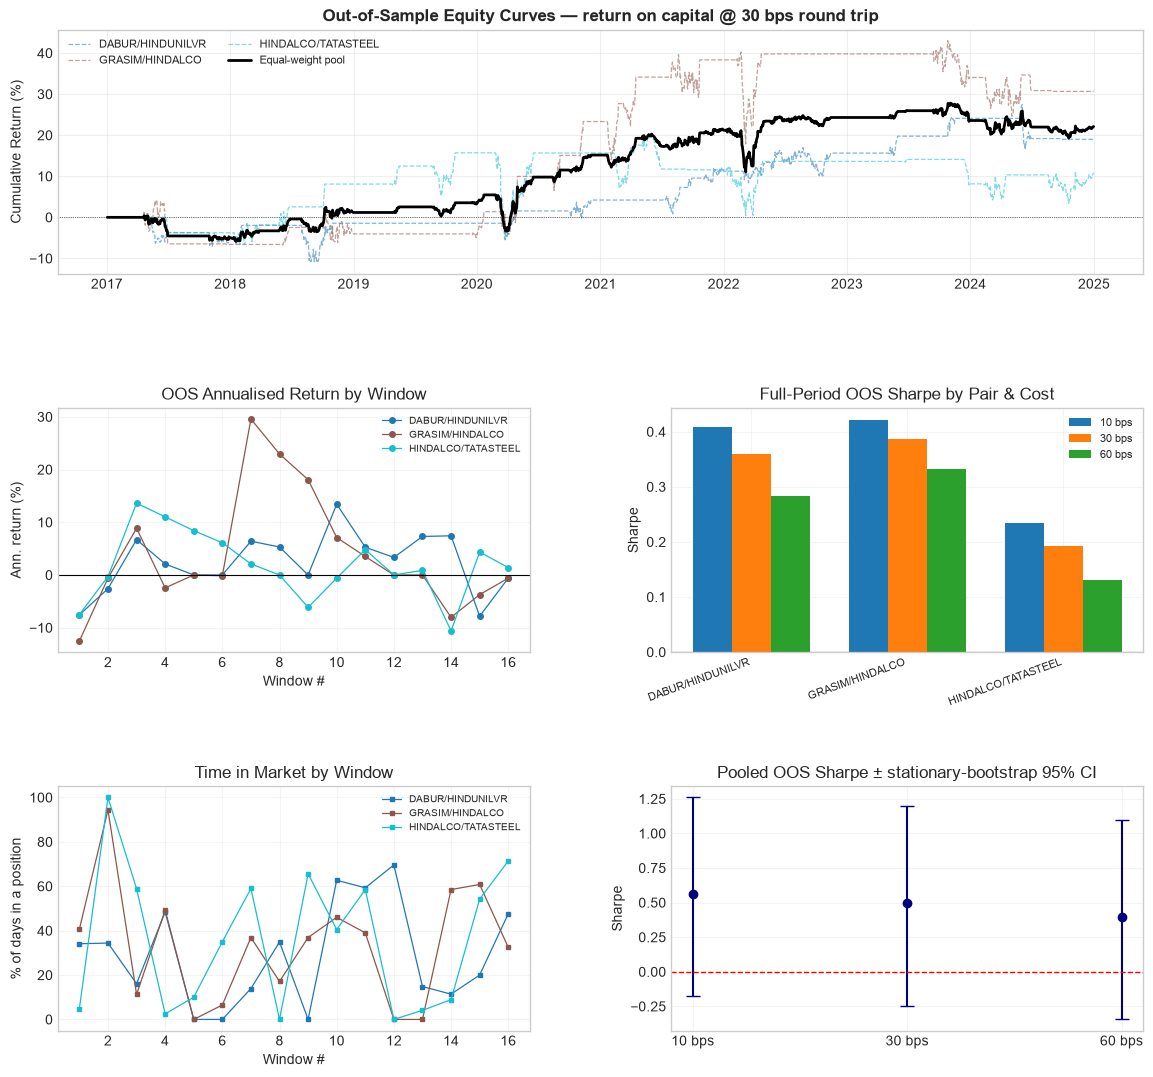

In [8]:
base = COST_BPS_ROUND_TRIP
wf_base = wf[base]
pair_labels = [f'{a}/{b}'.replace('.NS', '') for a, b in PAIRS]
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(PAIRS), 1)))

fig = plt.figure(figsize=(14, 13))
gs  = gridspec.GridSpec(3, 2, hspace=0.55, wspace=0.3)

# ── 1. OOS equity curves — bounded, on capital (base cost) ──────────────
ax1 = fig.add_subplot(gs[0, :])
for k, col in enumerate(oos_panel.columns):
    ci = (1 + oos_panel[col].fillna(0)).cumprod() - 1
    ax1.plot(ci * 100, linewidth=0.9, alpha=0.55, linestyle='--',
             color=cmap[k], label=col.replace('.NS', ''))
ax1.plot(oos_cum * 100, color='black', linewidth=2.0, label='Equal-weight pool')
ax1.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax1.set_title(f'Out-of-Sample Equity Curves — return on capital @ {base} bps round trip',
              fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(fontsize=8, ncol=2); ax1.grid(alpha=0.3)

# ── 2. Per-window OOS return, coloured by pair (base cost) ──────────────
ax2 = fig.add_subplot(gs[1, 0])
for k, (key, wdf) in enumerate(wf_base.items()):
    ax2.plot(wdf['Window'], wdf['OOS Return % (ann)'], marker='o', markersize=4,
             linewidth=0.9, color=cmap[k], label=f'{key[0]}/{key[1]}'.replace('.NS', ''))
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('OOS Annualised Return by Window'); ax2.set_xlabel('Window #')
ax2.set_ylabel('Ann. return (%)'); ax2.legend(fontsize=7); ax2.grid(alpha=0.2)

# ── 3. Full-period OOS Sharpe by pair x cost ───────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
x = np.arange(len(PAIRS)); w = 0.25
for j, cost in enumerate(COST_LEVELS):
    vals = per_pair_by_cost[cost]['Full-period OOS Sharpe'].values
    ax3.bar(x + (j - 1) * w, vals, w, label=f'{cost} bps')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_xticks(x); ax3.set_xticklabels(pair_labels, rotation=20, ha='right', fontsize=8)
ax3.set_title('Full-Period OOS Sharpe by Pair & Cost'); ax3.set_ylabel('Sharpe')
ax3.legend(fontsize=8); ax3.grid(alpha=0.2)

# ── 4. Time in market by window ────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
for k, (key, wdf) in enumerate(wf_base.items()):
    ax4.plot(wdf['Window'], wdf['Time in Mkt %'], marker='s', markersize=3,
             linewidth=0.9, color=cmap[k], label=f'{key[0]}/{key[1]}'.replace('.NS', ''))
ax4.set_title('Time in Market by Window'); ax4.set_xlabel('Window #')
ax4.set_ylabel('% of days in a position'); ax4.legend(fontsize=7); ax4.grid(alpha=0.2)

# ── 5. Pooled Sharpe: point estimate + bootstrap 95% CI, by cost ───────
ax5 = fig.add_subplot(gs[2, 1])
pts = [pooled_by_cost[c]['sharpe'] for c in COST_LEVELS]
lo  = [pooled_by_cost[c]['ci_sharpe'][0] for c in COST_LEVELS]
hi  = [pooled_by_cost[c]['ci_sharpe'][1] for c in COST_LEVELS]
xc  = np.arange(len(COST_LEVELS))
ax5.errorbar(xc, pts, yerr=[np.array(pts) - lo, np.array(hi) - pts],
             fmt='o', capsize=5, color='navy')
ax5.axhline(0, color='red', linestyle='--', linewidth=1)
ax5.set_xticks(xc); ax5.set_xticklabels([f'{c} bps' for c in COST_LEVELS])
ax5.set_title('Pooled OOS Sharpe ± stationary-bootstrap 95% CI')
ax5.set_ylabel('Sharpe'); ax5.grid(alpha=0.2)

plt.savefig('walk_forward_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ══ In-sample vs out-of-sample — SAME strategy, different period ═════════
# Both sides use config.rolling_zscore + config.pair_backtest + the full-series
# sharpe_ratio, at the base cost. Training windows overlap (roll 6m, span 24m),
# so IS is summarised per window and averaged; OOS is summarised the same way
# for a like-for-like gap. The only thing that differs is train vs test period.
BASE = COST_BPS_ROUND_TRIP

def insample_window_sharpes(a_col, b_col):
    A, B = prices[a_col], prices[b_col]
    out = []
    for train_s, train_e, _, _ in windows:
        a_tr = A.loc[train_s:train_e].dropna()
        b_tr = B.loc[train_s:train_e].dropna()
        if len(a_tr) < 60:
            continue
        spread_tr, beta, _ = ols_spread(a_tr, b_tr)
        z_tr = rolling_zscore(spread_tr)                     # same Z-score as OOS
        bt   = pair_backtest(a_tr, b_tr, beta, z_tr, cost_bps_round_trip=BASE)
        out.append(sharpe_ratio(bt['ret']))
    return pd.Series(out, dtype=float)

rows, is_pool, oos_pool = [], [], []
for (a_col, b_col) in PAIRS:
    is_s  = insample_window_sharpes(a_col, b_col).dropna()
    oos_s = wf[BASE][(a_col, b_col)]['OOS Sharpe'].dropna()
    is_pool += is_s.tolist(); oos_pool += oos_s.tolist()
    rows.append({
        'Pair':                f'{a_col}/{b_col}',
        'IS mean Sharpe':      round(is_s.mean(), 3),
        'OOS mean Sharpe':     round(oos_s.mean(), 3),
        'Gap (IS - OOS)':      round(is_s.mean() - oos_s.mean(), 3),
        'OOS full-period Sh.': round(sharpe_ratio(pair_oos_series(BASE, (a_col, b_col))), 3),
    })
gap_df = pd.DataFrame(rows)
print(f'=== IN-SAMPLE vs OUT-OF-SAMPLE SHARPE  (same method, @ {BASE} bps round trip) ===')
print(gap_df.to_string(index=False))

is_pool, oos_pool = np.array(is_pool), np.array(oos_pool)
print(f'\nPooled IS  mean per-window Sharpe : {np.nanmean(is_pool):+.3f}  (n={len(is_pool)})')
print(f'Pooled OOS mean per-window Sharpe : {np.nanmean(oos_pool):+.3f}  (n={len(oos_pool)})')
print(f'Overfitting gap (IS - OOS)        : {np.nanmean(is_pool) - np.nanmean(oos_pool):+.3f}')
print(f'IS > OOS (overfitting signal)     : {np.nanmean(is_pool) > np.nanmean(oos_pool)}')

=== IN-SAMPLE vs OUT-OF-SAMPLE SHARPE  (same method, @ 30 bps round trip) ===
                    Pair  IS mean Sharpe  OOS mean Sharpe  Gap (IS - OOS)  OOS full-period Sh.
  DABUR.NS/HINDUNILVR.NS           0.706            0.359           0.347                0.359
   GRASIM.NS/HINDALCO.NS           0.872            0.244           0.627                0.387
HINDALCO.NS/TATASTEEL.NS           0.952           -0.108           1.060                0.193

Pooled IS  mean per-window Sharpe : +0.843  (n=48)
Pooled OOS mean per-window Sharpe : +0.158  (n=40)
Overfitting gap (IS - OOS)        : +0.685
IS > OOS (overfitting signal)     : True


## Conclusion

### How to read the output

| Signal | Reading |
|--------|---------|
| Per-pair full-period OOS Sharpe > 0 across all three cost levels | Edge survives realistic costs for that pair |
| Bootstrap 95% CI for pooled Sharpe excludes 0 | Pooled edge distinguishable from noise (but see caveat) |
| Bootstrap CI straddles 0 | Not distinguishable from noise at this sample size |
| IS mean Sharpe ≫ OOS mean Sharpe | Overfitting — in-sample fit does not carry over |
| High zero-trade-window count | Signal fires rarely; per-window means are thin |

### Safeguards in this notebook
- **Pairs from NB08** — `data/top_pairs.csv` read directly; missing file raises.
- **One Z-score, one P&L model** — `config.rolling_zscore` and `config.pair_backtest`; no per-notebook re-implementation.
- **P&L is a return on capital** — bounded below by −100% by construction, asserted.
- **Sharpe over the full series** — flat days count; time-in-market reported alongside.
- **Every window kept** — a quiet window is a zero, not a deletion.
- **Costs swept 10 / 30 / 60 bps** — every level reported, no cherry-picking.
- **Pooled inference by bootstrap** — the pair-windows are not independent (shared HINDALCO leg, common calendar); a stationary block bootstrap replaces the invalid t-test, and the per-pair numbers are the primary finding.